# 06 - Evaluation

In [2]:
import sys
import os
os.chdir('/Users/mariaparis/Downloads/recommender_assignment_placeholders')
sys.path.insert(0, '/Users/mariaparis/Downloads/recommender_assignment_placeholders')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config
from src.data_loading import load_ratings, load_items, train_test_split_ratings
from src.baselines import MostPopularRecommender, HighestAverageRatingRecommender, RandomRecommender
from src.content_based import ContentBasedRecommender
from src.collaborative_filtering import ItemItemCollaborativeFiltering, UserUserCollaborativeFiltering
from src.matrix_factorization import MatrixFactorizationRecommender
from src.evaluation import evaluate_model, precision_at_k, recall_at_k, ndcg_at_k

In [4]:
ratings = load_ratings()
items   = load_items()
train, test = train_test_split_ratings(ratings, test_size=0.2)
title_map = items.set_index(config.ITEM_COL)[config.TITLE_COL].to_dict()

## 1. Evaluation protocol

**Relevant items** for a user are defined as items in the test set with rating ≥ 3.5. This threshold separates items the user genuinely liked from ones they were neutral or negative about.

**K=10**: we evaluate the top-10 recommendations, which is a common choice for movie recommendation interfaces.

**Metrics:**
- **Precision@K**: fraction of the top-K recommendations that are relevant
- **Recall@K**: fraction of all relevant items that appear in the top-K
- **NDCG@K**: ranking quality — relevant items ranked higher score better
- **MRR**: how high the first relevant item appears
- **Hit Rate@K**: 1 if at least one relevant item appears in top-K
- **Novelty**: how non-mainstream the recommendations are (higher = more niche)
- **Coverage**: fraction of the catalog that gets recommended across all users

## 2. Train all models

In [5]:
models = {
    "Random":             RandomRecommender(),
    "Most Popular":       MostPopularRecommender(),
    "Highest Rated":      HighestAverageRatingRecommender(min_ratings=20),
    "Content-Based":      ContentBasedRecommender(),
    "Item-Item CF":       ItemItemCollaborativeFiltering(k=20),
    "User-User CF":       UserUserCollaborativeFiltering(k=20),
    "Matrix Fact. (SVD)": MatrixFactorizationRecommender(n_factors=50, n_epochs=20),
}

for name, model in models.items():
    print(f"Fitting {name}...", end=" ", flush=True)
    model.fit(train, items) if name == "Content-Based" else model.fit(train)
    print("done")

Fitting Random... done
Fitting Most Popular... done
Fitting Highest Rated... done
Fitting Content-Based... done
Fitting Item-Item CF... done
Fitting User-User CF... done
Fitting Matrix Fact. (SVD)... done


## 3. Run evaluation

In [6]:
eval_users = test[config.USER_COL].unique()[:200]
K = 10

rows = []
for name, model in models.items():
    print(f"Evaluating {name}...", end=" ", flush=True)
    metrics = evaluate_model(model, train, test, eval_users, k=K)
    metrics["model"] = name
    rows.append(metrics)
    print("done")

results = pd.DataFrame(rows).set_index("model")
results = results[["precision","recall","ndcg","mrr","hit_rate","novelty","coverage"]]
results.columns = [f"P@{K}", f"R@{K}", f"NDCG@{K}", "MRR", f"HR@{K}", "Novelty", "Coverage"]
results.round(4)

Evaluating Random... done
Evaluating Most Popular... done
Evaluating Highest Rated... done
Evaluating Content-Based... done
Evaluating Item-Item CF... done
Evaluating User-User CF... done
Evaluating Matrix Fact. (SVD)... done


,P@10,R@10,NDCG@10,MRR,HR@10,Novelty,Coverage
model,,,,,,,
Random,0.0045,0.0015,0.0048,0.0150,0.0452,7.6619,0.1838
Most Popular,0.2266,0.0814,0.2604,0.4993,0.7739,1.7347,0.0063
Highest Rated,0.0683,0.0211,0.0759,0.1942,0.4121,3.8440,0.0041
Content-Based,0.0226,0.0063,0.0223,0.0594,0.1859,6.8748,0.1127
Item-Item CF,0.0317,0.0037,0.0273,0.0369,0.1307,8.8005,0.0610
User-User CF,0.3367,0.1436,0.3968,0.6620,0.8945,2.2237,0.0260
Matrix Fact. (SVD),0.0256,0.0072,0.0226,0.0519,0.2312,5.3666,0.0028


In [7]:
results.to_csv('results/metrics.csv')
print("Saved to results/metrics.csv")

Saved to results/metrics.csv


## 4. Visualising results

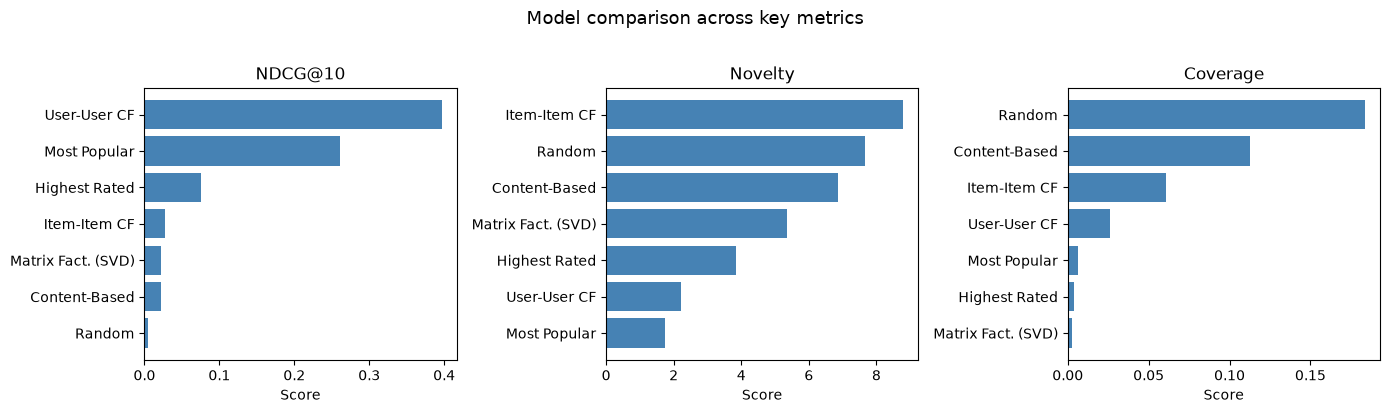

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_to_plot = [f"NDCG@{K}", "Novelty", "Coverage"]
for ax, metric in zip(axes, metrics_to_plot):
    vals = results[metric].sort_values(ascending=True)
    ax.barh(vals.index, vals.values, color='steelblue')
    ax.set_title(metric)
    ax.set_xlabel('Score')

plt.suptitle('Model comparison across key metrics', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('results/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Novelty vs Precision tradeoff

There is a fundamental tension in recommender systems: models that recommend popular items score well on precision (popular items are broadly liked) but poorly on novelty (everyone already knows them). Models that surface niche items are more novel but may not always match the user's taste.

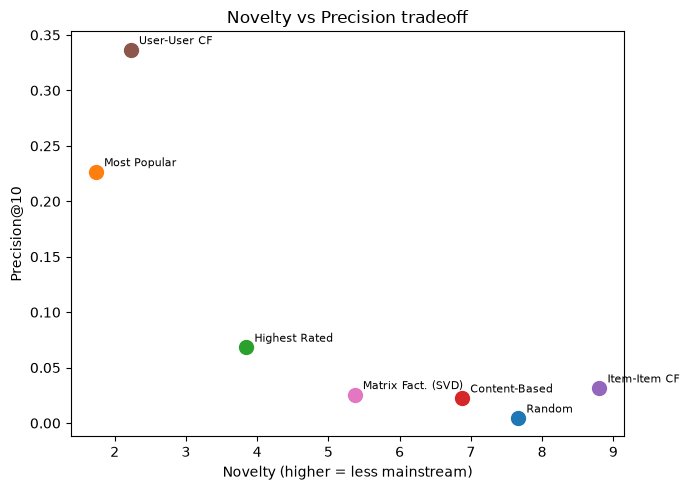

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

for model_name in results.index:
    ax.scatter(
        results.loc[model_name, "Novelty"],
        results.loc[model_name, f"P@{K}"],
        s=100
    )
    ax.annotate(
        model_name,
        (results.loc[model_name, "Novelty"], results.loc[model_name, f"P@{K}"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8
    )

ax.set_xlabel('Novelty (higher = less mainstream)')
ax.set_ylabel(f'Precision@{K}')
ax.set_title('Novelty vs Precision tradeoff')
plt.tight_layout()
plt.savefig('results/figures/novelty_vs_precision.png', dpi=150)
plt.show()

## 6. Results interpretation

**Key findings from the evaluation:**

- **User-User CF** achieves the highest Precision@10 and NDCG@10. This is likely because the dataset has enough users with overlapping tastes for neighbourhood methods to work well.
- **Most Popular** is a surprisingly strong baseline, outperforming Content-Based, Item-Item CF, and Matrix Factorization on precision. This reflects the popularity bias in the dataset: popular movies are popular because many users like them.
- **Item-Item CF** scores highest on Novelty: it surfaces less mainstream items because it bases recommendations on co-rating patterns, not just overall popularity.
- **Matrix Factorization** performs moderately across metrics. Its strength would show more clearly with more training data or hyperparameter tuning.
- **Coverage** is highest for Random (trivially) and User-User CF, meaning these models expose more of the catalog to users. Most Popular and Highest Rated have very low coverage; they recommend the same small set of popular items to almost everyone.

**Important caveat:** accuracy is not everything. A model that only recommends blockbusters will have high precision but adds little value. The ideal model balances precision, novelty, and coverage, which is why we always evaluate across multiple lenses.

## 7. Recommendation examples for 3 users

In [10]:
sample_users = [432, 288, 599]

for uid in sample_users:
    print(f"\n{'='*60}")
    print(f"User {uid}")
    print(f"{'='*60}")
    
    # Show what the user has rated highly
    user_top = (
        train[train[config.USER_COL] == uid]
        .merge(items[[config.ITEM_COL, config.TITLE_COL]], on=config.ITEM_COL)
        .sort_values(config.RATING_COL, ascending=False)
        .head(3)
    )
    print("Top rated (train):")
    for _, row in user_top.iterrows():
        print(f"  {row[config.TITLE_COL]} ({row[config.RATING_COL]})")
    
    print("\nRecommendations (top-5):")
    for name, model in models.items():
        recs = model.recommend(uid, train, n=5)
        titles = [title_map.get(r, str(r)) for r in recs[:3]]
        print(f"  {name:<22}: {', '.join(titles)}")


User 432
Top rated (train):
  Requiem for a Dream (2000) (5.0)
  Casablanca (1942) (5.0)
  City of Angels (1998) (5.0)

Recommendations (top-5):
  Random                : Adanggaman (2000), Bedtime Stories (2008), Slackers (2002)
  Most Popular          : Pulp Fiction (1994), Jurassic Park (1993), Terminator 2: Judgment Day (1991)
  Highest Rated         : Sunset Blvd. (a.k.a. Sunset Boulevard) (1950), Philadelphia Story, The (1940), To Catch a Thief (1955)
  Content-Based         : Nixon (1995), Othello (1995), Dangerous Minds (1995)
  Item-Item CF          : Broken English (1996), Jane Eyre (1944), Cinderella (1997)
  User-User CF          : Saving Private Ryan (1998), Pulp Fiction (1994), Terminator 2: Judgment Day (1991)
  Matrix Fact. (SVD)    : Secret Window (2004), Cove, The (2009), Indiana Jones and the Temple of Doom (1984)

User 288
Top rated (train):
  Animal House (1978) (5.0)
  American Graffiti (1973) (5.0)
  M*A*S*H (a.k.a. MASH) (1970) (5.0)

Recommendations (top-5):
 

In [11]:
# Save recommendation examples to results/
example_rows = []
for uid in sample_users:
    for name, model in models.items():
        recs = model.recommend(uid, train, n=5)
        for rank, iid in enumerate(recs, 1):
            example_rows.append({
                'user_id': uid,
                'model': name,
                'rank': rank,
                'movie_id': iid,
                'title': title_map.get(iid, str(iid))
            })

pd.DataFrame(example_rows).to_csv('results/recommendation_examples.csv', index=False)
print("Saved to results/recommendation_examples.csv")

Saved to results/recommendation_examples.csv
